In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [112]:
df = pd.read_csv(r"../data/raw/supply_chain_dataset.csv")
df.head()

,Product_ID,Warehouse,Order_Date,Shipment_Date,Lead_Time,Demand_Forecast,Inventory_Level,Stockout_Flag,Backorder_Flag,Supplier_ID,Order_Quantity,Shipment_Quantity,Product_Category,Product_Price,Customer_ID,Order_Priority
0,8270,A,1/1/2023,1/2/2023,8,839,481,0,0,397,98,40,Clothing,387.89,2014,High
1,1860,C,1/1/2023,1/2/2023,8,351,332,0,1,483,52,35,Furniture,891.03,6805,High
2,6390,C,1/1/2023,1/2/2023,5,398,156,0,0,160,34,43,Food,933.21,3833,Medium
3,6191,A,1/1/2023,1/2/2023,5,972,418,1,0,161,32,45,Electronics,628.57,3640,Medium
4,6734,D,1/1/2023,1/2/2023,3,529,428,0,0,325,44,41,Electronics,70.33,9297,Medium


In [100]:
df.shape

(9000, 16)

In [101]:
df.columns

Index(['Product_ID', 'Warehouse', 'Order_Date', 'Shipment_Date', 'Lead_Time',
       'Demand_Forecast', 'Inventory_Level', 'Stockout_Flag', 'Backorder_Flag',
       'Supplier_ID', 'Order_Quantity', 'Shipment_Quantity',
       'Product_Category', 'Product_Price', 'Customer_ID', 'Order_Priority'],
      dtype='object')

In [102]:
df['Revenue'] = df['Order_Quantity'] * df['Product_Price']

In [103]:
numerical_cols = [
    'Lead_Time',
    'Demand_Forecast',
    'Inventory_Level',
    'Order_Quantity',
    'Shipment_Quantity',
    'Product_Price'
]

In [104]:
df[numerical_cols].describe()

,Lead_Time,Demand_Forecast,Inventory_Level,Order_Quantity,Shipment_Quantity,Product_Price
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4.970556,551.367222,248.182444,50.296111,49.408889,503.122006
std,2.579402,259.098562,145.036179,28.958419,28.754420,287.872648
min,1.000000,100.000000,0.000000,1.000000,1.000000,10.140000
25%,3.000000,327.000000,123.000000,25.000000,25.000000,254.502500
50%,5.000000,555.000000,246.000000,51.000000,49.000000,497.550000
75%,7.000000,773.000000,375.000000,76.000000,74.000000,755.322500
max,9.000000,999.000000,499.000000,99.000000,99.000000,999.890000


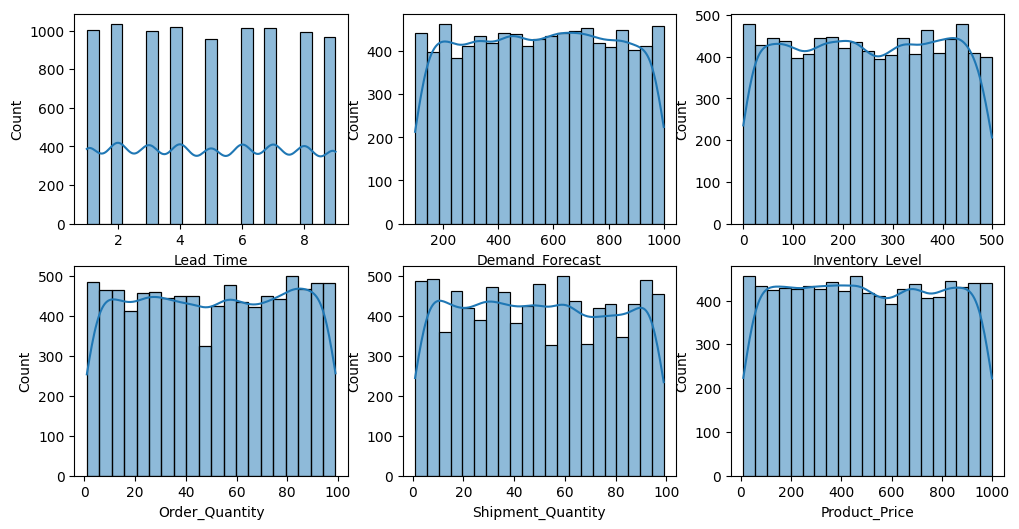

In [108]:
fig, axes = plt.subplots(2,3, figsize=(12,6))
axes = axes.flatten()
for i, col_name in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(data=df, x=col_name, ax=ax, kde=True)
plt.show()


In [106]:
categorical_cols = [
    'Warehouse',
    'Product_Category',
    'Order_Priority'
]

In [107]:
df['Warehouse'].value_counts()

Warehouse
D    2312
A    2238
B    2235
C    2215
Name: count, dtype: int64

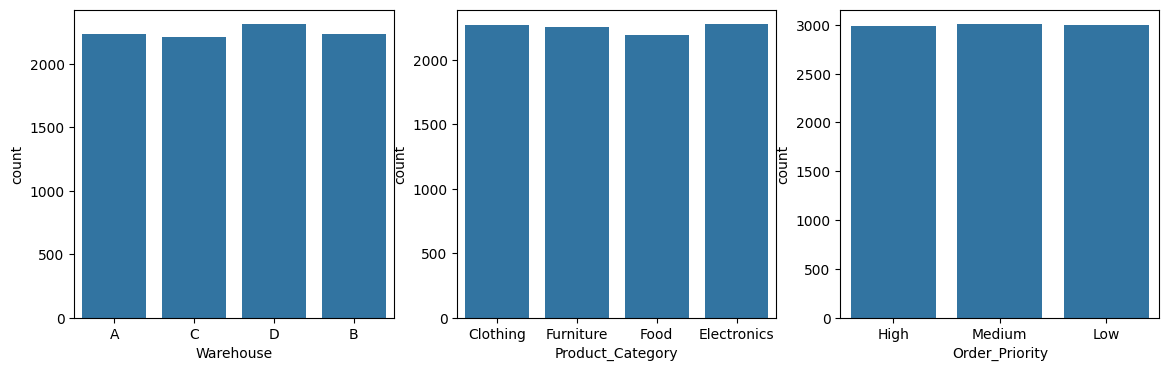

In [97]:
fig, axes = plt.subplots(1,3, figsize=(14,4))
axes = axes.flatten()
for i, col_name in enumerate(categorical_cols):
    ax = axes[i]
    sns.countplot(data=df, x=col_name, ax=ax)
plt.show()

In [64]:
df['Product_Category'].value_counts()

Product_Category
Electronics    2278
Clothing       2275
Furniture      2255
Food           2192
Name: count, dtype: int64

In [65]:
df['Order_Priority'].value_counts()

Order_Priority
Medium    3007
Low       3002
High      2991
Name: count, dtype: int64

<Axes: xlabel='Demand_Forecast', ylabel='Inventory_Level'>

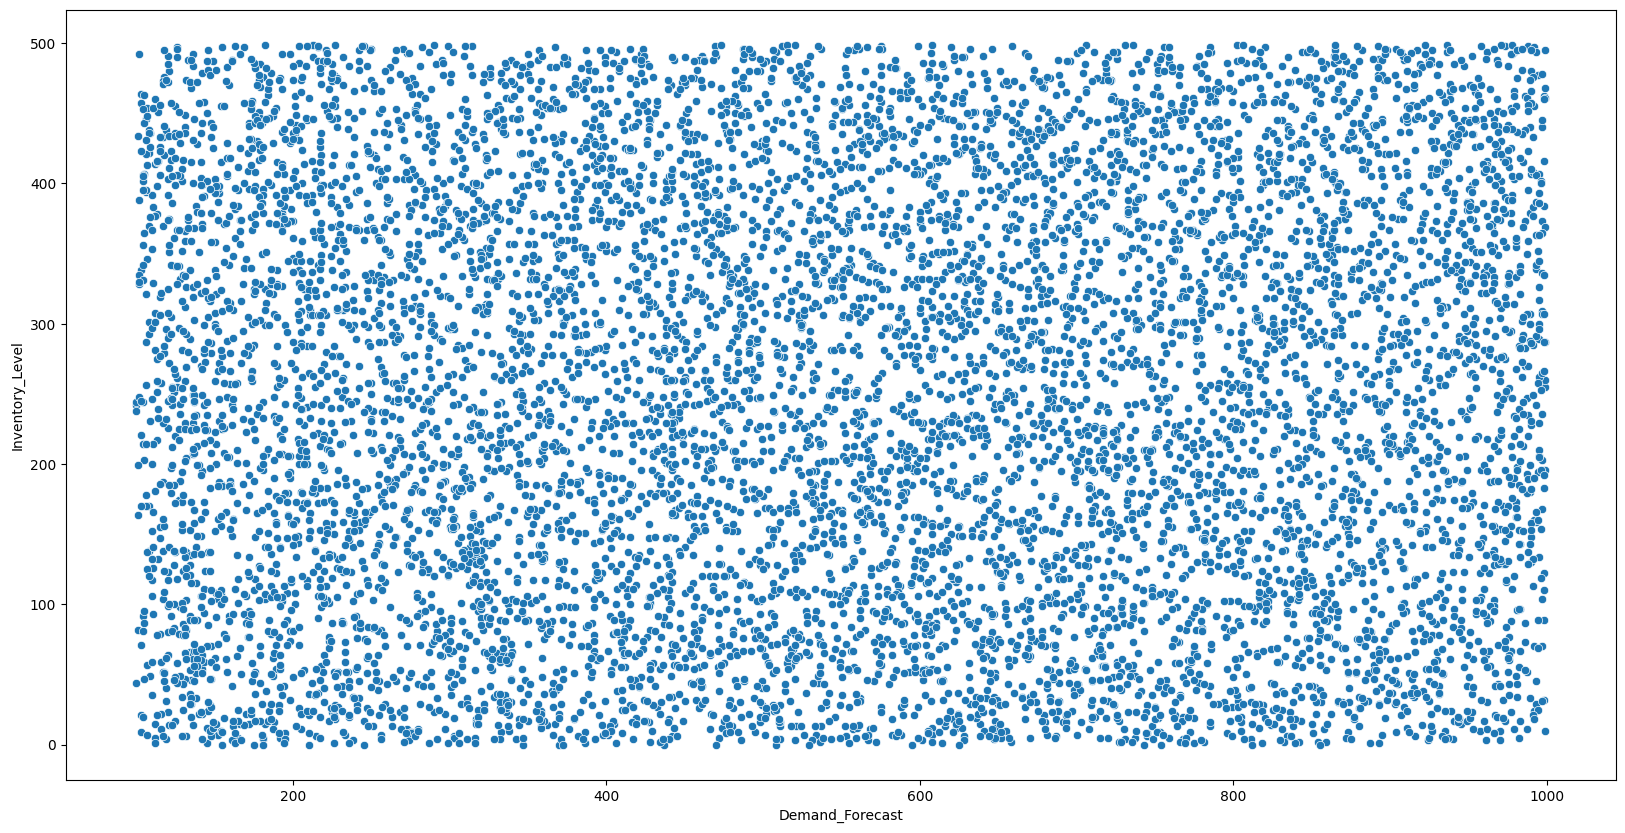

In [66]:
plt.figure(figsize=(20,10))
sns.scatterplot(
    data=df,
    x='Demand_Forecast',
    y='Inventory_Level'
)

<Axes: xlabel='Order_Quantity', ylabel='Shipment_Quantity'>

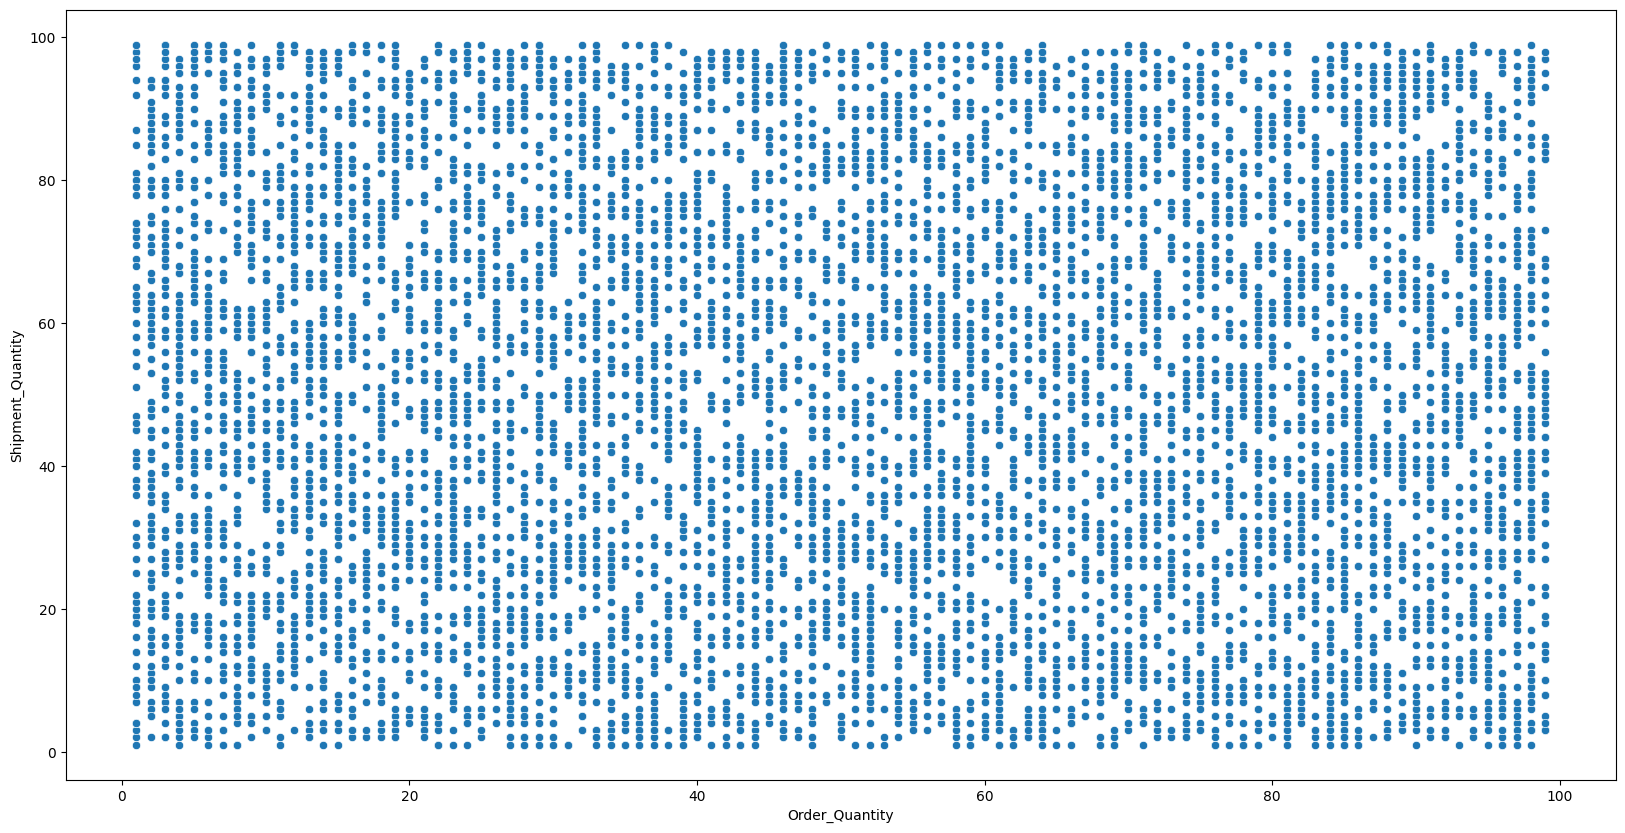

In [67]:
plt.figure(figsize=(20,10))
sns.scatterplot(
    data=df,
    x='Order_Quantity',
    y='Shipment_Quantity'
)

<Axes: xlabel='Backorder_Flag', ylabel='Lead_Time'>

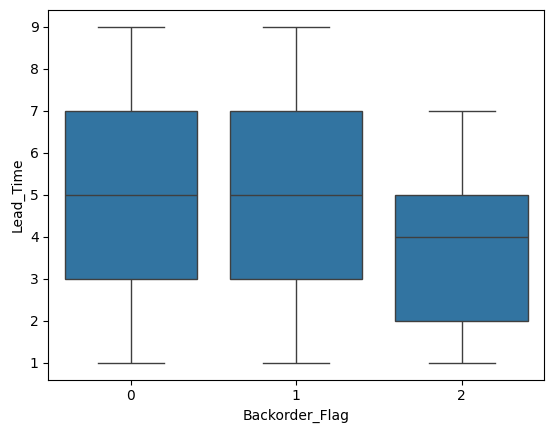

In [68]:
sns.boxplot(
    data=df,
    x='Backorder_Flag',
    y='Lead_Time'
)

<Axes: xlabel='Stockout_Flag', ylabel='Lead_Time'>

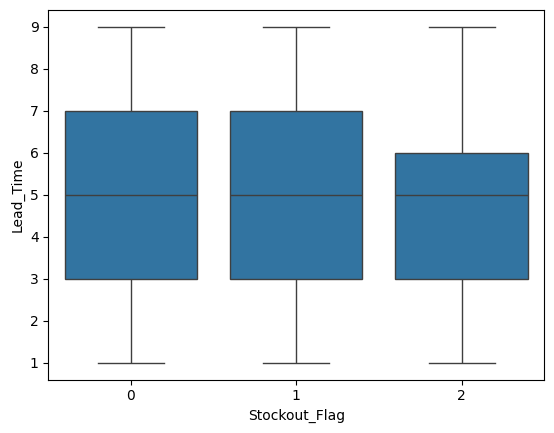

In [69]:
sns.boxplot(
    data=df,
    x='Stockout_Flag',
    y='Lead_Time'
)

In [109]:
corr = df[
    [
        'Lead_Time',
        'Demand_Forecast',
        'Inventory_Level',
        'Order_Quantity',
        'Shipment_Quantity',
        'Product_Price'
    ]
].corr()

<Axes: >

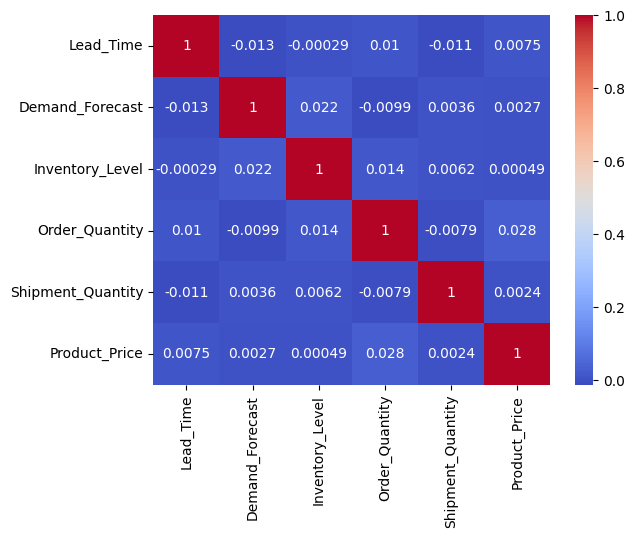

In [110]:
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

In [111]:
df.to_csv("../data/processed/clean_supply_chain.csv", index=False)

In [ ]:
# 1. Warehouse D processes the highest number of orders.

# 2. Demand Forecast and Shipment Quantity show a strong positive relationship.

# 3. Orders experiencing backorders tend to have higher lead times.

# 4. Inventory levels appear insufficient for several high-demand products.

# 5. Most orders belong to Medium priority.